In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, roc_curve, auc, confusion_matrix, 
ConfusionMatrixDisplay)

In [21]:
# Step 2: Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42)

In [22]:
# ── Decision Tree using GINI INDEX ───
gini_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
gini_model.fit(X_train, y_train)
y_pred_gini = gini_model.predict(X_test)
print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))
print(classification_report(y_test, y_pred_gini))

Gini Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        63
           1       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [28]:
# ── Decision Tree using Entropy ───
entropy_model = DecisionTreeClassifier(criterion="entropy", max_depth=5,random_state=42)
entropy_model.fit(X_train, y_train)
y_pred_entropy = entropy_model.predict(X_test)
print("Entropy Accuracy:", accuracy_score(y_test, y_pred_entropy))
print(classification_report(y_test, y_pred_entropy))

Entropy Accuracy: 0.9532163742690059
              precision    recall  f1-score   support

           0       0.97      0.90      0.93        63
           1       0.95      0.98      0.96       108

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



In [27]:
if accuracy_score(y_test, y_pred_gini) > accuracy_score(y_test, y_pred_entropy):
    print("Conclusion: Gini performed better than Entropy.")
elif accuracy_score(y_test, y_pred_gini) < accuracy_score(y_test, y_pred_entropy):
    print("Conclusion: Entropy performed better than Gini.")
else:
    print("Conclusion: Both models achieved the same accuracy.")

Conclusion: Gini performed better than Entropy.


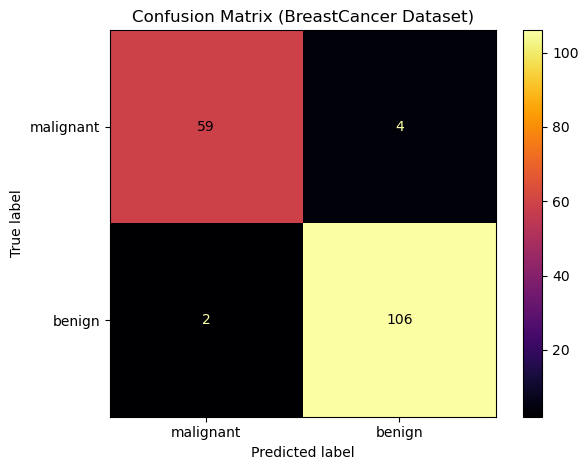

In [24]:
cm=confusion_matrix(y_test, y_pred_gini)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="inferno")
plt.title("Confusion Matrix (BreastCancer Dataset)")
plt.tight_layout()
plt.show()

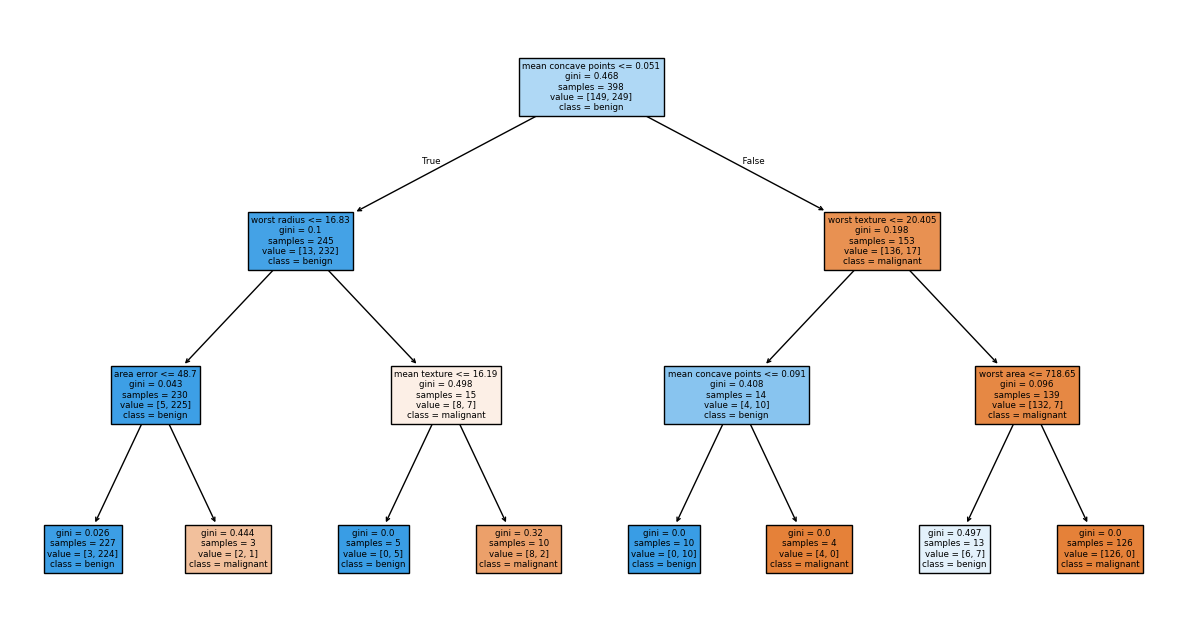

In [25]:
plt.figure(figsize=(15,8))
plot_tree(
    gini_model,
    filled=True,
    feature_names=data.feature_names,
    class_names=data.target_names
)
plt.show()

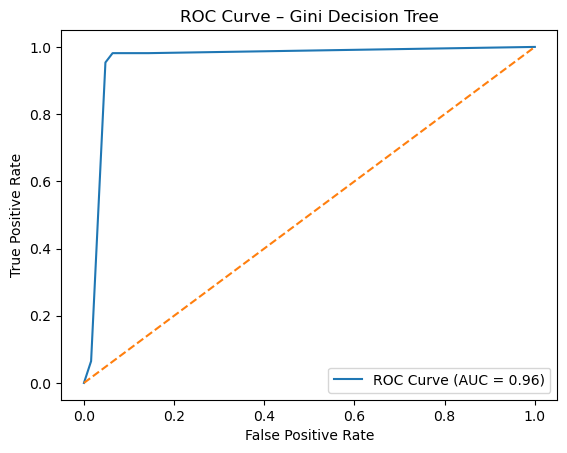

In [26]:
y_prob = gini_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Gini Decision Tree")
plt.legend()
plt.show()